# Prosjekt 3

## Task 1

>**Task 1.1**

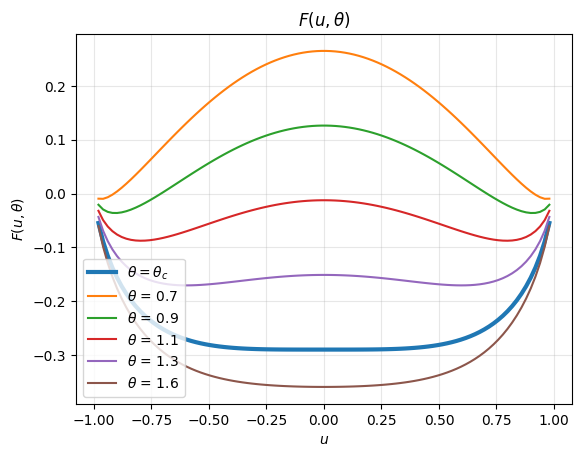

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

theta_c = 1.5 # Critical temperature
theta_arr = np.array([0.7, 0.9, 1.1, 1.3, 1.6]) # Different values for temperature
u = np.linspace(-1,1, 100)[1:-1] # Slicing to avoid using -1 and 1

def F(u, theta):
    '''
    Plots the energy density, F(u), for different values of theta.

    Variables,
      u : concentration of mass (float)
      theta : temperature (array<float>)

    Returns,
      F(u) : energy density (float)
    '''
    return (theta_c / 2) * (1-u**2) + (theta/2) * ( (1-u) * np.log((1-u)/2) + (1+u) * np.log((1+u)/2) )

plt.plot(u,F(u, theta_c), label = f'$\\theta = \\theta_c$', linewidth=3)
for theta in theta_arr:
    plt.plot(u,F(u, theta), label = f'$\\theta$ = {theta}')

plt.legend(loc= 'lower left')
plt.xlabel('$u$')
plt.ylabel('$F(u, \\theta )$')
plt.title('$F(u, \\theta)$')
plt.grid(alpha = 0.3)
plt.show()

>**Task 1.2**


From the Cahn-Hilliard equation, given by
\begin{align}
    \partial_tu  -  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0,
\end{align}
where $u = u(\vec{x}, t) \ \vert \ \vec{x} = (x,y)$, we will observe step by step what happens under the transformation $u \rightarrow-u$.

By the linearity of the derivative, we have that
\begin{align}
    \partial_tu &\rightarrow \partial_t(-u) = -\partial_tu \\
    \nabla^2u &\rightarrow \nabla^2(-u) = -\nabla^2u,\\
\end{align}
and since $f$ is an anti-symmetric function, we have that
\begin{align}
    f(u) &\rightarrow f(-u) = -f(u)\\
    \implies  M\nabla\left(f(u)-\kappa\nabla^2u \right) &\rightarrow M\nabla\left(f(-u)+\kappa\nabla^2u \right) = -M\nabla\left(f(u)-\kappa\nabla^2u \right) \\
    \implies \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) &\rightarrow -\nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right).
\end{align}
Hence, we have that the equation as a whole transforms into,
\begin{align}
    &\partial_tu  -  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0 \\ \rightarrow& -\partial_tu  +  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0\\
    &\partial_tu  -  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0
\end{align}
Thus, $-u$ also solves the Cahn-Hilliard equation, and it is invariant under the transformation.

q.e.d

>**Task 1.3**

Taking the Cahn-Hilliard equation as stated above, multiplying by 1, and integrating over $\Omega = [0,L_x) \times[0,L_y)$, we get,
\begin{equation}
    \int_{\Omega}\partial_tu \ d\vec{x}  - \int_{\Omega} \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) \ d\vec{x} = 0.
\end{equation}
The first integral has integration domain independent of the partial derivative operator inside the integral, and we can therefore move the derivative operator outside, and make it a total derivative,
\begin{equation}
    \int_{\Omega}\partial_tu \ d\vec{x} = \frac{d}{dt}\int_{\Omega}u \ d\vec{x}.
\end{equation}
Continuing, we want to use the divergence theorem, which is generally stated as
\begin{equation}   
\int_{\Omega} (\nabla \cdot \mathbf{F}) \, dV = \oint_{\partial \Omega}\hat{n}\cdot \mathbf{F}  \ dS,
\end{equation}
with $\hat{n}$ being the outward-pointing unit normal to the boundary $ \partial \Omega $, and $dS$ representing the surface element of the boundary.
In our case, we can define
\begin{equation}
    \mathbf{F}(x,y) = M\nabla\left(f(u)-\kappa\nabla^2u \right)
\end{equation}
and by the periodicity of our domain, we have that $\mathbf{F}(0,y) = \mathbf{F}(L_x, y)$ and $\mathbf{F}(x,0) = \mathbf{F}(x, L_y)$.

Taking a look at the boundary and its direction, plotted here,

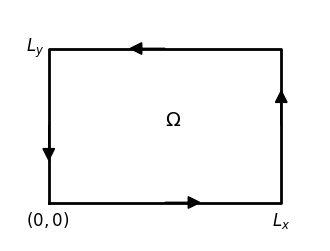

In [ ]:
def draw_omega_domain():
    # Define rectangle dimensions
    Lx, Ly = 3, 2

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(4, 3))

    # Draw rectangle
    ax.plot([0, Lx, Lx, 0, 0], [0, 0, Ly, Ly, 0], 'k-', linewidth=2)

    # Arrow size
    arrow_size = 0.3
    head_size = 0.15

    # Add arrows in the middle of each boundary segment
    ax.arrow(Lx/2, 0, arrow_size, 0, head_width=head_size, head_length=head_size, fc='black', ec='black')  # Bottom edge
    ax.arrow(Lx, Ly/2, 0, arrow_size, head_width=head_size, head_length=head_size, fc='black', ec='black')  # Right edge
    ax.arrow(Lx/2, Ly, -arrow_size, 0, head_width=head_size, head_length=head_size, fc='black', ec='black')  # Top edge
    ax.arrow(0, Ly/2, 0, -arrow_size, head_width=head_size, head_length=head_size, fc='black', ec='black')  # Left edge

    # Add labels
    ax.text(-0.3, -0.3, r'$(0,0)$', fontsize=12)
    ax.text(Lx, -0.3, r'$L_x$', fontsize=12, ha='center')
    ax.text(-0.3, Ly, r'$L_y$', fontsize=12, va='center')
    ax.text(Lx/2, Ly/2, r'$\Omega$', fontsize=14)

    # Adjust axes
    ax.set_xlim(-0.5, Lx + 0.5)
    ax.set_ylim(-0.5, Ly + 0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    # Show plot
    plt.show()

draw_omega_domain()

we clearly see that the integral over the left and right boundary segments will cancel out, and likewise with the top and bottom of the boundary. Thus
\begin{equation}   
\oint_{\partial \Omega}\hat{n}\cdot \mathbf{F}  \ dS = 0
\end{equation}
and we are left with
\begin{equation}
    \frac{d}{dt}\int_{\Omega}u \ d\vec{x} = 0.
\end{equation}
The system is therefore mass-conservative since we showed that the boundary integral, which could be considered the mass-flux throug our domain, is in total zero.

q.e.d

## Task 2

By Fourier-transformation of the biharmonic equation with a linear term we get
\begin{align}
    \Delta^2u +  cu& = f \\
    \mathcal{F}[\Delta^2 u +cu] &= \hat{f} \\
    \mathcal{F}[\Delta^2u] +c\hat{u} &= \hat{f} \\
    (i\tilde{k})^4\hat{u}+c\hat{u} &= \hat{f}\\
    (\lvert\tilde{k}\rvert^4+c)\hat{u} &= \hat{f}.
\end{align}

So our operator transforms as $\{\Delta^2 + c\}\rightarrow\{\lvert\tilde{k}\rvert^4+c\}$ under the Fourier transform, which will be implemented in the code under.

In [ ]:
from scipy.fft import fft2, ifft2, fftfreq

def biharmonic_solver(X, Y, F, c, mean=0.0):
    """
    Solve the biharmonic equation in 2D using the spectral method.

    Parameters:
        X (array)   : 2D array of x-coordinates.
        Y (array)   : 2D array of y-coordinates.
        F (array)   : 2D array representing the right-hand side of the biharmonic equation.
        c (float)   : Constant coefficient in the biharmonic equation.
        mean (float): Desired mean value of the solution in case c = 0. Default is 0.0.

    Returns:
        U (array)   : 2D array representing the solution to the biharmonic equation.
    """

    F_hat = fft2(F) # Compute the FFT of the right-hand side using the 2D FFT

    # Size of the grid and length
    Nx, Ny = X.shape
    Lx, Ly = (X.max() - X.min()), (Y.max() - Y.min())

    # Transforms the 2D space to a Fourier frequency space
    kx, ky = fftfreq(Nx, d=Lx/(Nx-1))* 2j * np.pi, fftfreq(Ny, d=Ly/(Ny-1)) * 2j * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)

    # Computing the biharmonic operator in Fourier space
    K_op = (KX**2 + KY**2)**2 + c
    if c == 0: K_op[0, 0] = 1  # Avoid division by zero

    # Solve the biharmonic equation in Fourier space
    U_hat = F_hat / K_op
    if c == 0: U_hat[0, 0] = mean * Nx * Ny # Corrects the K_op = 0 scenario by setting it as a mean value

    U = ifft2(U_hat).real # Compute the inverse FFT to obtain the final solution in spatial domain

    return U

In [ ]:
import sympy as sy
from sympy import sin, cos, exp

def biharmonic_solver_sym(u_str, c):
    """
    Uses SymPy to solve the biharmonic equation (f(x, y) = Δ²u + c * u) for a given string of the function u(x, y).
    Returns the function u(x, y) and f(x, y) as NumPy functions. Also prints them out to check for correct input and output.

    Parameters:
        u_str (str) : String representation of the function u(x, y).
        c (float)   : Constant coefficient in the biharmonic equation.

    Returns:
        u (function) : NumPy-compatible function representing u(x, y).
        f (function) : NumPy-compatible function representing f(x, y).
    """

    x, y = sy.symbols('x y') # Define symbolic variables x and y
    u_sy = eval(u_str)       # Convert the input string representation of u into a SymPy expression

    # Solves the equation with SymPy functions
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)
    f_sy = sy.simplify(biharmonic_op(u_sy) + (c * u_sy))

    # Print out the symbolic expressions for verification
    print(f'u = {u_sy}')
    print(f'f = {f_sy}')

    # Convert symbolic expressions into NumPy-compatible functions
    u = sy.lambdify((x, y), u_sy, modules='numpy')
    f = sy.lambdify((x, y), f_sy, modules='numpy')

    return u, f

u_ex_str2_1 = "sin(8*(x - 1)) * cos(4*y)"
u_ex_str2_2 = "exp((sin(x))**2 + cos(2*y))"
u_ex2_1, f2_1 = biharmonic_solver_sym(u_ex_str2_1, 1)
u_ex2_2, f2_2 = biharmonic_solver_sym(u_ex_str2_2, 0)

u = sin(8*x - 8)*cos(4*y)
f = 6401*sin(8*x - 8)*cos(4*y)
u = exp(sin(x)**2 + cos(2*y))
f = (16*sin(x)**8 + 64*sin(x)**6 + 128*sin(x)**4*sin(y)**4 - 192*sin(x)**4*sin(y)**2 + 16*sin(x)**4 - 48*sin(x)**2 + 256*sin(y)**8 - 1280*sin(y)**6 + 1792*sin(y)**4 - 768*sin(y)**2 + 52)*exp(sin(x)**2 + cos(2*y))


In [ ]:
# Define the domain
Lx0, Ly0 = 2*np.pi, 4*np.pi

# Define 1d samplings for x and y directions
Nx1 = np.array([4, 8, 15, 16, 20, 32])
Ny1 = 2* Nx1
Nx2 = np.array([4, 8, 12, 16, 20, 24, 28, 32, 36, 40])
Ny2 = 2* Nx2

def compute_EOC(Nx_arr, Ny_arr, Lx, Ly, u_ex, f, c):
    """
    Perform convergence study for given grid sizes, calculating errors and EOCs.

    Parameters:
        Nx_arr (array)  : List of Nx grid sizes to test.
        Ny_arr (array)  : List of Ny grid sizes corresponding to Nx.
        Lx (float)      : Length of the domain in the x-direction.
        Ly (float)      : Length of the domain in the y-direction.
        u_ex (function) : Exact solution function, u_ex(X, Y).
        f (function)    : Right-hand side function, f(X, Y).
        c (float)       : Constant in the biharmonic equation.

    Returns:
        errors (array) : Array of errors for each grid size.
        EOCs (array)   : Array of EOC values for successive grid sizes.
    """
    errors_list = []

    # Loop over grid sizes
    for i in range(len(Nx_arr)):
        Nx, Ny = Nx_arr[i], Ny_arr[i]
        x = np.linspace(0, Lx, Nx, endpoint=False)
        y = np.linspace(0, Ly, Ny, endpoint=False)
        X, Y = np.meshgrid(x, y, indexing='ij')

        # Evaluate exact solution and right-hand side
        U_exact = u_ex(X, Y)
        F = f(X, Y)

        mean_ex = np.mean(U_exact)

        # Solve numerical solution
        U_num = biharmonic_solver(X, Y, F, c, mean=mean_ex)

        # Compute max-norm error
        errors_list.append(np.max(np.abs(U_num - U_exact)))

    errors = np.array(errors_list)

    # Compute EOC values
    d = Lx/Nx_arr
    EOCs = np.log(errors[1:]/errors[:-1])/np.log(d[1:]/d[:-1])

    return errors, EOCs

def plot_convergence(Ni_list, Ni_name, errors, EOCs):
    """
    Plot the errors and EOCs in a table format.

    Parameters:
        Ni_list (list): List of Ni grid sizes.
        Ni_name (string): Name of the grid we are looking at.
        errors (np.ndarray): Array of errors.
        EOCs (np.ndarray): Array of EOC values.
    """
    print(f"\n{Ni_name:<15}{'Error':<25}{'EOC':<15}")
    print("-" * 60)
    for i in range(len(Ni_list)):
        EOC = EOCs[i-1] if i > 0 else None
        if EOC is None:
            print(f"{Ni_list[i]:<15}{errors[i]:<25.6e}{'--':<15}")
        else:
            print(f"{Ni_list[i]:<15}{errors[i]:<25.6e}{EOC:<15.4f}")

# Run convergence studies
errors2_1, EOCs2_1 = compute_EOC(Nx1, Ny1, Lx0, Ly0, u_ex2_1, f2_1, c=1)
errors2_2, EOCs2_2 = compute_EOC(Nx2, Ny2, Lx0, Ly0, u_ex2_2, f2_2, c=0)

# Plot the results
print("\nConvergence studies for u(x, y) = " + u_ex_str2_1 + ":")
plot_convergence(Nx1, "Nx", errors2_1, EOCs2_1)
print("\n\nConvergence studies for u(x, y) = " + u_ex_str2_2 + ":")
plot_convergence(Nx2, "Nx", errors2_2, EOCs2_2)


Convergence studies for u(x, y) = sin(8*(x - 1)) * cos(4*y):

Nx             Error                    EOC            
------------------------------------------------------------
4              6.331893e+03             --             
8              2.365221e+01             8.0645         
15             5.136364e-01             6.0923         
16             6.550316e-15             495.7198       
20             4.130030e-14             -8.2519        
32             4.740652e-14             -0.2934        


Convergence studies for u(x, y) = exp((sin(x))**2 + cos(2*y)):

Nx             Error                    EOC            
------------------------------------------------------------
4              2.024104e+01             --             
8              1.062305e+01             0.9301         
12             9.844063e-01             5.8667         
16             3.462556e-02             11.6359        
20             9.929320e-04             15.9166        
24             3.6019

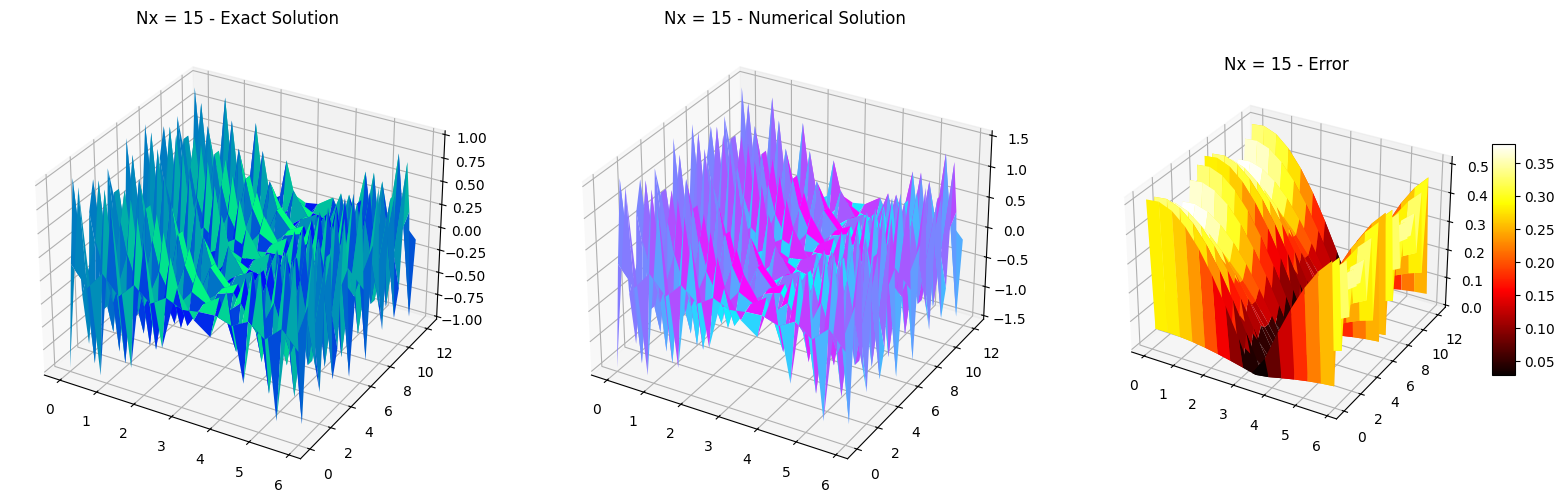

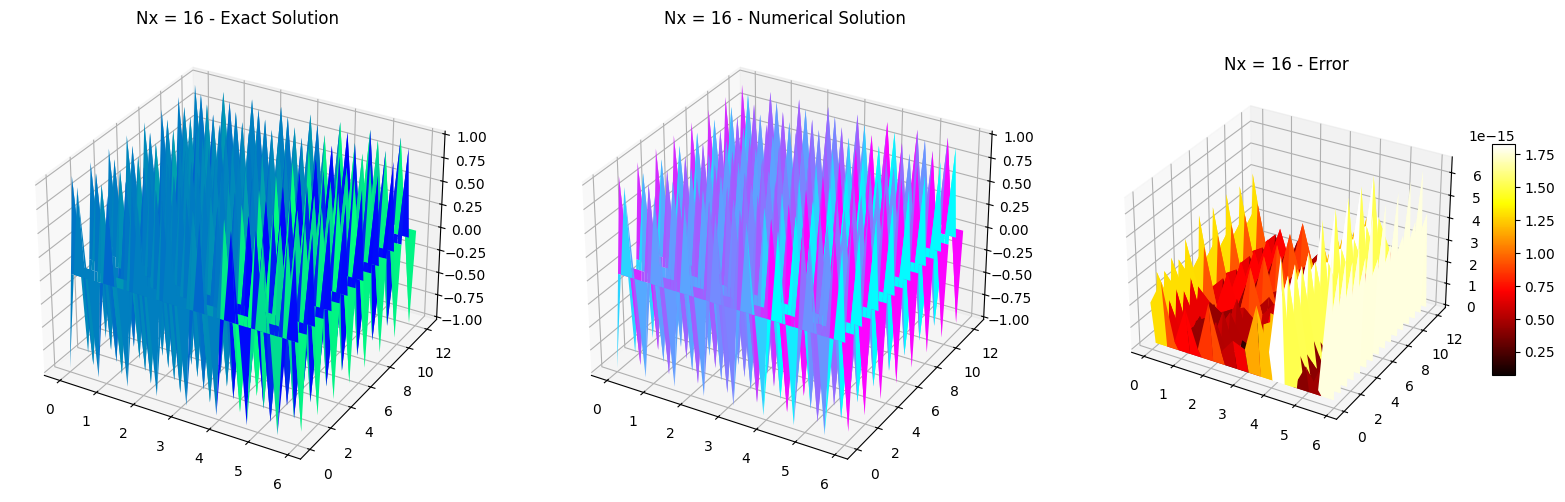

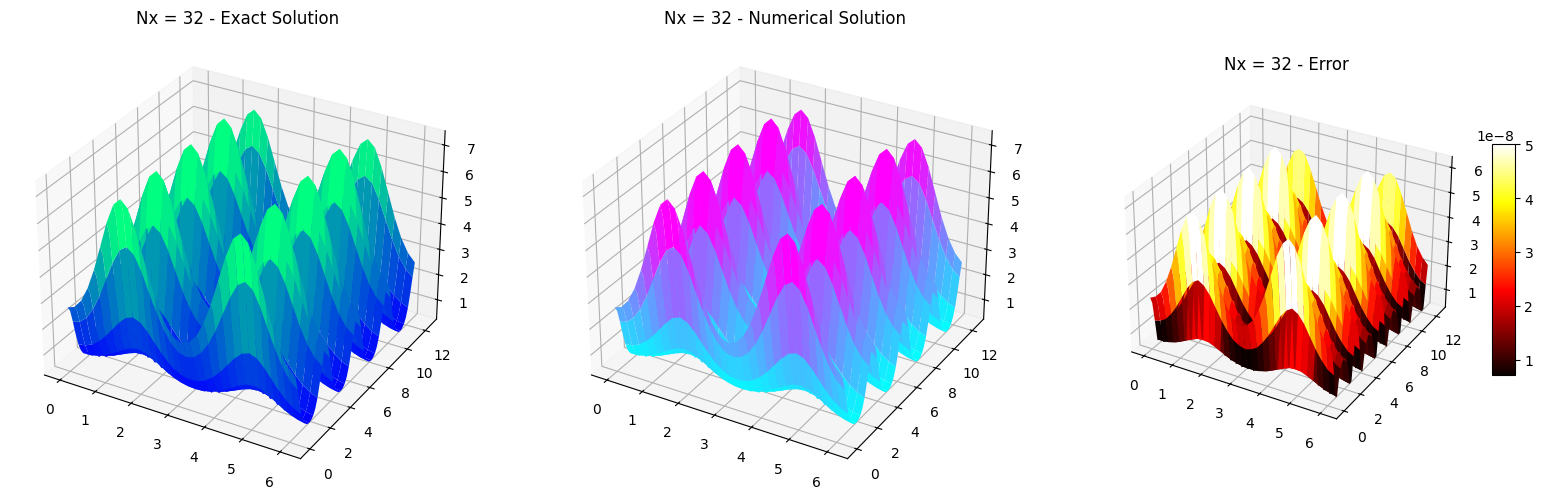

In [ ]:
def plot_surface(X, Y, U_exact, U_num, error, title):
    """
    Plots 3D surface graphs for the exact solution, numerical solution, and error of a function
    on a given grid.

    Parameters:
        X (array)       : 2D array of x-coordinates for the grid.
        Y (array)       : 2D array of y-coordinates for the grid.
        U_exact (array) : 2D array representing the exact solution values at (X, Y).
        U_num (array)   : 2D array representing the numerical (computed) solution values at (X, Y).
        error (array)   : 2D array representing the difference between U_exact and U_num.
        title (str)     : Title for the plots.
    """

    fig = plt.figure(figsize=(20, 6))

    # Plot exact solution
    ax1 = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(X, Y, U_exact, cmap='winter')
    ax1.set_title(f'{title} - Exact Solution')

    # Plot numerical solution
    ax2 = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(X, Y, U_num, cmap='cool')
    ax2.set_title(f'{title} - Numerical Solution')

    # Plot error
    ax3 = fig.add_subplot(133, projection='3d')
    surf3 = ax3.plot_surface(X, Y, error, cmap='hot')
    ax3.set_title(f'{title} - Error')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

    plt.show()

Nx_values = np.array([15, 16, 32])
Ny_values = 2 * Nx_values

# Loops all the plotting og the grid sizes and functions wich
for i, Nx in enumerate(Nx_values):
    Ny = Ny_values[i]
    x = np.linspace(0, Lx0, Nx, endpoint=False)
    y = np.linspace(0, Ly0, Ny, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Evaluate exact solution and right-hand side
    U_exact = u_ex2_1(X, Y) if i < 2 else u_ex2_2(X, Y)
    F = f2_1(X, Y) if i < 2 else f2_2(X, Y)
    mean = np.mean(U_exact)

    # Solve numerical solution
    U_num = biharmonic_solver(X, Y, F, 1, mean=mean) if i < 2 else biharmonic_solver(X, Y, F, 0, mean=mean)

    # Compute error
    error = np.abs(U_num - U_exact)

    # Plot the surfaces for each case
    plot_surface(X, Y, U_exact, U_num, error, f"Nx = {Nx}")

52.88846365589663 0.23358733080235827


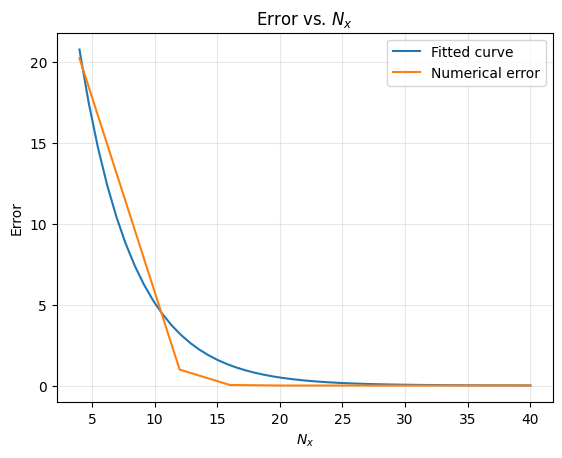

In [ ]:
from scipy.optimize import curve_fit

# Further error and EOC analysis for 2nd expression
def exp_decay(x, A, B):
    return A*np.exp(-B*x)


x = np.linspace(Nx2[0], Nx2[-1])
params, _          = curve_fit(exp_decay, Nx2, errors2_2, p0=[52,.2])
A_fitted, B_fitted = params
print(A_fitted, B_fitted)

error_fit = exp_decay(x, A_fitted, B_fitted)

plt.plot(x, error_fit, label = 'Fitted curve')
plt.plot(Nx2, errors2_2, label = 'Numerical error')
plt.title(r"Error vs. $N_x$")
plt.xlabel(r"$N_x$")
plt.ylabel(r"Error")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Task 3 Theoretical

>**Task 3.1**

We are given the equation
\begin{align}
    U_{n+1} = U_n + \tau \left( \theta F(t_{n+1}, U_{n+1}) + (1 - \theta) F(t_n, U_n) \right), \quad \text{for } n = 0, 1, \dots, N-1
\end{align}
and have that
\begin{align}
    k_1 &= F(t_n, U_n) \\
    k_2 &= F(t_{n+1}, U_{n+1}).
\end{align}

For $k_2$, we insert the equation for $U_{n+1}$ first mentioned into the expression and get
\begin{align}
    k_2 &= F(t_n+\tau, U_n + \tau(\theta k_2+(1-\theta)k_1))
\end{align}





This gives us a butcher table as
\
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1-\theta & \theta \\
\hline
& 1 - \theta & \theta \\
\end{array}




From the butcher table, we can easily check the consistency order of the $\theta$-method.
The $p = 1$ condition, which says
\begin{equation}
    \sum_{i=1}^{2}b_i = (1-\theta) + \theta = 1 \ \forall\ \theta,
\end{equation}
is satisfied. Now taking a look at $p = 2$, which states
\begin{equation}
    \sum_{i=1}^2 b_ic_i = (1-\theta)\cdot0+ \theta\cdot1 = \theta\neq \frac{1}{2} \ \forall \ \theta,
\end{equation}
we see that the condition is not generally satisfied. It does however hold for $\theta = \frac{1}{2}$. So assuming $\theta = \frac{1}{2}$ going forward, we compute the condition for $p = 3$,
\begin{equation}
    \sum_{i=1}^2b_ic_2^2 = \frac{1}{2}\cdot 0^2 + \frac{1}{2}\cdot 1^2 = \frac{1}{2}\neq \frac{1}{3}.
\end{equation}
So the condition for consistency order $p=3$ does not hold.
Therefore, we conclude that $p = 1\ \forall \ \theta \neq \frac{1}{2}$ and $p=2 \ \vert \ \theta = \frac{1}{2}$

For $\theta = \frac{1}{2}$, the method reduces to the Crank-Nicolson method, which is based on the implicit trapezoid rule.
For $\theta = 0$, we get the explicit euler method, and for $\theta = 1$ we are left with the implicit euler method.

#3.2

We use the butcher table for our $\theta$-method, and the ODE $\partial_tU_n = \lambda U_n = F(t_n,U_n)$ to get,
    \begin{align}
        U_{n+1} &= U_n + \tau (\theta\lambda U_{n+1} + (1-\theta)\lambda U_n) \\
        &= (1+\tau(1-\theta)\lambda U_n + \tau\theta\lambda U_{n+1}\\
        (1-\theta z) U_{n+1} &= (1+(1-\theta)z)U_n\\
        U_{n+1} &= \left(\frac{1+(1-\theta)z}{1-\theta z}\right) U_n = \left(\frac{1+(1-\theta)z}{1-\theta z}\right)^n U_0
    \end{align}
So our stability function becomes
    \begin{equation}
        r_\theta(z) = \frac{1+(1-\theta)z}{1-\theta z}.
    \end{equation}
Below, we have included some heatmaps of the magnitude of the stability function in the complex plane.

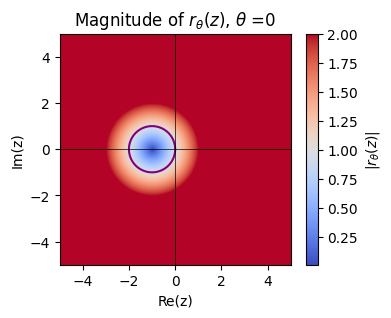

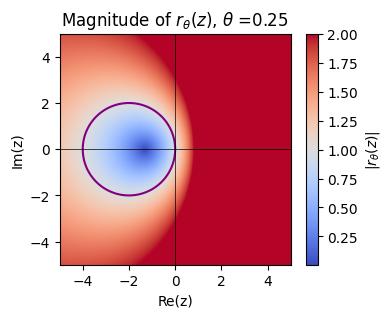

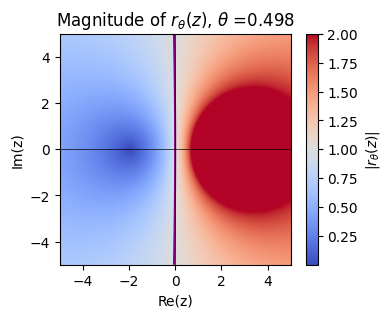

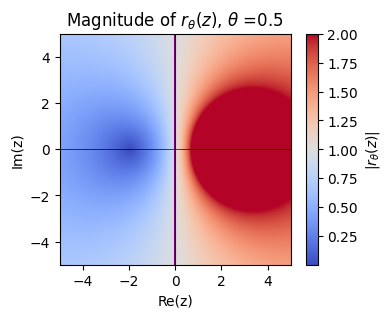

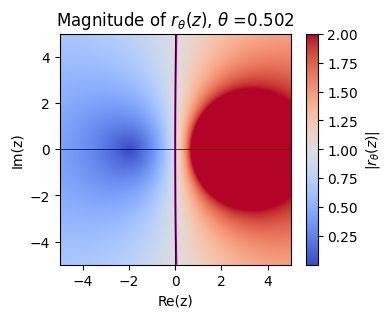

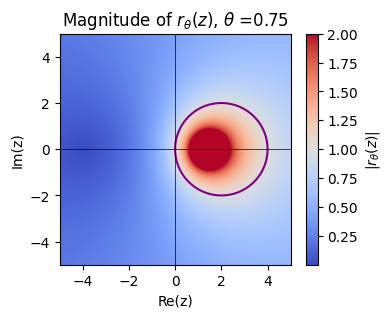

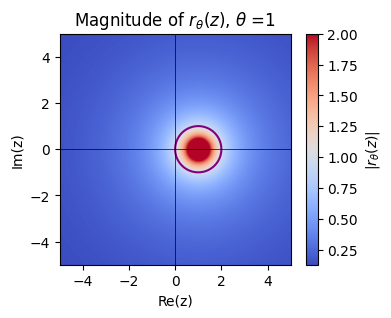

In [ ]:
def r_theta(z, theta):
  return (1 + (1-theta)*z) / (1-theta*z)
n = 5

Re = np.linspace(-n, n, 500)
Im = np.linspace(-n, n, 500)

X, Y = np.meshgrid(Re, Im)

Z = X + 1j*Y

theta_arr = [0, .25, .498, .5, .502, .75, 1]


for theta in theta_arr:
    R= r_theta(Z, theta)

    plt.figure(figsize = (4,3))
    plt.contour(X, Y, np.abs(R), levels=[1], colors='purple', linewidths=1.5)
    plt.imshow(np.abs(R), extent=[-n, n, -n, n], origin="lower", cmap="coolwarm", vmax = 2)
    plt.colorbar(label= r"|$r_\theta (z)$|")
    plt.axhline(0, color='black', linewidth=.5)  # x-axis
    plt.axvline(0, color='black', linewidth=.5)  # y-axis
    plt.xlabel("Re(z)")
    plt.ylabel("Im(z)")
    plt.title(r"Magnitude of $r_\theta (z)$, $\theta$ ="+f"{theta}")
    plt.show()

#3.3

To find an expression for $\partial S_\theta = \{ z \in \mathbb{C} \ \vert \ \lvert r_\theta(z) \rvert = 1\}$ we use the stabitity function and multiply by the complex conjugate to find how the radius on the boundary depends on the argument of $z$ and $\theta$.
\begin{align}
    \lvert1+(1-\theta)z\rvert &= \lvert1 -\theta z\rvert \\
    \left(+(1-\theta)z\right)\left(+(1-\theta)\bar{z}\right) &= \left(1 -\theta z\right)\left(1 -\theta \bar{z}\right) \\
    1+(1-\theta)(\bar{z}+z) + (1-\theta)^2z\bar{z} &= -\theta(z+\bar{z})+\theta^2z\bar{z}\\
    (1-\theta)(z+\bar{z}) + (1-\theta)^2\lvert z\rvert^2 &= -\theta(z+\bar{z})+\theta^2\lvert z \rvert^2\\
    (\bar{z} +z) +\lvert z\rvert ^2 -2\theta \lvert z\rvert ^2 +\theta ^2\lvert z\rvert ^2 &= \theta^2 \lvert z\rvert ^2\\
    2Re\{z\} &= (2\theta -1) \lvert z\rvert ^2 \\
    \lvert z\rvert ^2 &= \frac{2Re\{z\}}{2\theta -1}.
\end{align}
Rewriting in polar coordinates, $z = \lvert z\rvert e^{i\phi}$ and solving for $\lvert z\rvert$ we get,
\begin{align}
    \lvert z\rvert ^2 &= \frac{2\lvert z\rvert \cos{\phi}}{2\theta-1}\\
    \lvert z\rvert  &= \frac{2\cos{\phi}}{2\theta-1}.
\end{align}
This expression for the boundary, parameterized by the argument of $z$, corresponds perfectly with the plotted boundaries in the heatmaps previously discussed, as shown in the following plot.


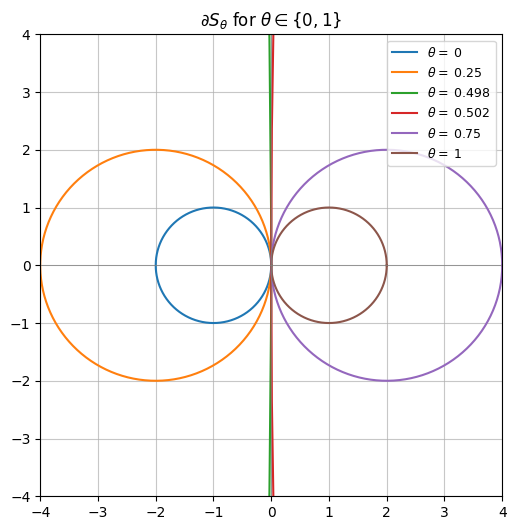

In [ ]:
def abs_r(theta,phi):
    return (2*np.cos(phi))/(2*theta-1)


phi = np.linspace(0,2*np.pi,1000)

plt.figure(figsize=(6,6))
for theta in theta_arr:
    if theta == .5:
      continue

    # Compute the modulus
    radius = np.clip(abs_r(theta, phi),0,1e10)

    # Convert to Cartesian coordinates
    x = radius * np.cos(phi)
    y = radius * np.sin(phi)

    # Plot
    plt.plot(x, y, label=r'$\theta =$ '+f'{theta}')

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal')  # Ensure aspect ratio is 1:1
plt.legend(fontsize = 9, loc = 'upper right')
plt.title(r"$\partial S_\theta$ for $\theta \in \{0,1\}$")
plt.grid(alpha=0.7)
plt.show()

To see how the center depends on $\theta$, we find the real part by evaluating $\frac{\lvert z\rvert}{2}\vert_{\phi=0}$,
\begin{equation}
    R_{center} = \frac{\cos{0}}{2\theta-1} = \frac{1}{2\theta-1}
\end{equation}

##Task 3 Numerical

In [ ]:
def transient_biharmonic_solver(*, kappa,
                                   X, Y, U0,
                                   t0, T, Nt,
                                   theta=0.5,
                                   g=None):
    """
    Solve the transient biharmonic equation using the theta method.

    Parameters:
    -----------
    kappa (float) : Diffusion coefficient.
    X (ndarray)   : 2D array of x-coordinates.
    Y (ndarray)   : 2D array of y-coordinates.
    U0 (ndarray)  : Initial condition array.
    t0 (float)    : Initial time.
    T (float)     : Final time.
    Nt (int)      : Number of time steps.
    g (callable, optional): Source term function g(X, Y, t). Defaults to None.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """

    if g is None:
        g = lambda X, Y, t, kappa: np.zeros_like(X)
    # Prepare relevant data for Fourier transform
    x, y = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    Lx, Ly = x.max() - x.min(), y.max() - y.min()

    kx, ky = fftfreq(Nx, d=Lx/(Nx-1)) * 2j * np.pi, fftfreq(Ny, d=Ly/(Ny-1)) * 2j * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)

    # Computing the biharmonic operator in Fourier space
    K_op = kappa*(KX**2 + KY**2)**2

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Add your time-stepping loop here
    t = t0
    dt = (T-t0)/Nt

    yield U_hat, t

    while t < T-dt/2:
        # Solve for next time step and update time
        g_hat_n = fft2(g(X, Y, t, kappa))
        g_hat_np1 = fft2(g(X, Y, t + dt, kappa))
        F_n = g_hat_n - U_hat * K_op

        U_hat = (U_hat + dt * ( theta * g_hat_np1 + (1-theta) * F_n )) / (1 + dt * theta * K_op)

        t += dt
        yield U_hat, t

In [ ]:
def solve_for_lambda(u_str):
    x, y, t, kappa, lambd = sy.symbols('x y t kappa lambd') # Define symbolic variables x, y and t
    u_sy = eval(u_str)                                      # Convert the input string representation of u into a SymPy expression
    u_ex = sy.lambdify((x, y, t, lambd, kappa), u_sy, modules='numpy')

    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2) # Biharmonic operator of u(x, y, t)
    dt_u          = lambda u: sy.diff(u, t, 1)                                                          # Differentiate u(x, y, t) with respect to t

    equation        = sy.Eq(dt_u(u_sy) + (kappa *  biharmonic_op(u_sy)), 0) # Sets up the equation ∂t u_ex + κ Δ² u_ex = 0
    lambda_solution = int(sy.solve(equation, lambd)[0]) # Solves the equation for kappa (κ)

    return u_ex, lambda_solution

u_ex_str3 = "sin(x)*cos(y)*exp(-lambd*kappa*t)"
u_ex3, lambd = solve_for_lambda(u_ex_str3)
print(lambd)

4


In [ ]:
Lx, Ly = 2*np.pi, 2*np.pi
Nx, Ny = 20, 20
x, y = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False), np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')
kappa = 1
t0 = 0
T = 1
theta_arr = np.array([1, 0.5, 0])

U0 = u_ex3(X, Y, 0, lambd, kappa)

Nt_arr = np.array([10, 20, 40, 80, 160, 320, 640])

def compute_EOC_transient(X, Y, Nt_arr, t0, T, u_ex, lambd, kappa, theta, g=None):
    errors_list = []

    # Loop over Nt values
    for i in range(len(Nt_arr)):
      errors_per_Nt_list =[]
      solver = transient_biharmonic_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt_arr[i], theta=theta, g=g)

      for U_hat, t in solver:
          U_num = ifft2(U_hat).real
          U_ex = u_ex(X, Y, t, lambd, kappa)
          errors_per_Nt_list.append(np.max(np.abs(U_num - U_ex)))

      errors_list.append(max(errors_per_Nt_list))

    errors = np.array(errors_list)

    # Compute EOC values
    d = (T-t0)/Nt_arr
    EOCs = np.log(errors[1:]/errors[:-1])/np.log(d[1:]/d[:-1])

    return errors, EOCs


for theta in theta_arr:
    errors3, EOCs3 = compute_EOC_transient(X, Y, Nt_arr, t0, T, u_ex3, lambd, kappa, theta)
    print("\nConvergence studies for u(x, y) = " + u_ex_str3 + " for theta =", theta, ":")
    plot_convergence(Nt_arr, "Nt", errors3, EOCs3)


Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-lambd*kappa*t) for theta = 1.0 :

Nt             Error                    EOC            
------------------------------------------------------------
10             6.323727e-02             --             
20             3.399813e-02             0.8953         
40             1.766385e-02             0.9447         
80             9.010042e-03             0.9712         
160            4.551183e-03             0.9853         
320            2.287346e-03             0.9926         
640            1.146639e-03             0.9963         

Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-lambd*kappa*t) for theta = 0.5 :

Nt             Error                    EOC            
------------------------------------------------------------
10             4.897916e-03             --             
20             1.231609e-03             1.9916         
40             3.068988e-04             2.0047         
80             7.666231e-05   

<ipython-input-11-350064ec0009>:51: RuntimeWarning: overflow encountered in multiply
  F_n = g_hat_n - U_hat * K_op
<ipython-input-11-350064ec0009>:53: RuntimeWarning: invalid value encountered in multiply
  U_hat = (U_hat + dt * ( theta * g_hat_np1 + (1-theta) * F_n )) / (1 + dt * theta * K_op)


In [ ]:
N_CFL = 20000
N_CFL_arr = np.array([0.5*N_CFL, N_CFL, 2*N_CFL, 4*N_CFL])

theta = 0

errors3, EOCs3 = compute_EOC_transient(X, Y, N_CFL_arr, t0, T, u_ex3, lambd, kappa, theta)
print("\nConvergence studies for u(x, y) = " + u_ex_str3 + " for theta =", theta, ":")
plot_convergence(N_CFL_arr, "Nt = N_CFL", errors3, EOCs3)

<ipython-input-11-350064ec0009>:51: RuntimeWarning: overflow encountered in multiply
  F_n = g_hat_n - U_hat * K_op
<ipython-input-11-350064ec0009>:53: RuntimeWarning: invalid value encountered in multiply
  U_hat = (U_hat + dt * ( theta * g_hat_np1 + (1-theta) * F_n )) / (1 + dt * theta * K_op)


In [ ]:
def transient_biharmonic_solver_sym(u_str):
    """
    FIX

    Parameters:
        u_str (str) : String representation of the function u(x, y).


    Returns:
        u (function) : NumPy-compatible function representing u(x, y).
        g (function) : NumPy-compatible function representing g(x, y).
    """

    x, y, t, kappa, lambd = sy.symbols('x y t kappa lambd') # Define symbolic variables x and y
    u_sy = eval(u_str)       # Convert the input string representation of u into a SymPy expression

    # Solves the equation with SymPy functions
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)
    dt_u          = lambda u: sy.diff(u, t, 1)

    g_sy = sy.simplify(sy.diff(u_sy, t, 1) + kappa*biharmonic_op(u_sy))

    # Print out the symbolic expressions for verification
    print(f'u = {u_sy}')
    print(f'g = {g_sy}')

    # Convert symbolic expressions into NumPy-compatible functions
    u = sy.lambdify((x, y, t, kappa, lambd), u_sy, modules='numpy')
    g = sy.lambdify((x, y, t, kappa), g_sy, modules='numpy')

    return u, g


u_ex_str3 = '( exp(1 + sin(x) * sin(x)) + exp(1 + cos(y) * cos(y))) * exp(-4 * kappa * t)'
u_ex3, g3 = transient_biharmonic_solver_sym(u_ex_str3)

U0 = u_ex3(X, Y, 0, kappa, lambd)

theta_arr = np.array([1, 0.5])

for theta in theta_arr:
    errors3, EOCs3 = compute_EOC_transient(X, Y, Nt_arr, t0, T, u_ex3, lambd, kappa, theta, g=g3)
    print("\nConvergence studies for u(x, y) = " + u_ex_str3 + " for theta =", theta, ":")
    plot_convergence(Nt_arr, "Nt", errors3, EOCs3)

u = (exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*kappa*t)
g = 4*kappa*((4*sin(x)**8 + 16*sin(x)**6 - 4*sin(x)**4 - 12*sin(x)**2 + 1)*exp(sin(x)**2 + 1) + (4*sin(y)**8 - 32*sin(y)**6 + 68*sin(y)**4 - 44*sin(y)**2 + 5)*exp(cos(y)**2 + 1) - exp(sin(x)**2 + 1) - exp(cos(y)**2 + 1))*exp(-4*kappa*t)

Convergence studies for u(x, y) = ( exp(1 + sin(x) * sin(x)) + exp(1 + cos(y) * cos(y))) * exp(-4 * kappa * t) for theta = 1.0 :

Nt             Error                    EOC            
------------------------------------------------------------
10             7.619971e+00             --             
20             7.288745e+00             0.0641         
40             7.182203e+00             0.0212         
80             7.083480e+00             0.0200         
160            7.033847e+00             0.0101         
320            7.008801e+00             0.0051         
640            6.995542e+00             0.0027         

Convergence studies for u(x, y) = ( exp(1 + sin(x) * sin(x))

## Task 4

#4.1

Using the given IMEX scheme for the Cahn-Hilliard equation with constant mobility $M = 1$ from the theoretical introduction to this task, but with the slight alteration of adding an implicit evaluation of $g$ at the right hand side, i.e.,
\begin{equation}
    \frac{u_{n+1}-u_{n}}{\tau} + \kappa\lvert\tilde{k}\rvert^4\Delta^2u_{n+1} - a\Delta u_{n+1} = \Delta\left((u_n)^3-(1+a)u_n\right) + g_{n+1}
\end{equation}
rewriting this equation to the form $U_{n+1} + \tau\mathbf{L}U_{n+1} = U_n \mathbf{N}(U_n) + g_{n+1}$, we get
\begin{equation}
    u_{n+1} + \tau\{\kappa\Delta^2 -a\Delta\}u_{n+1} = u_n+\tau\{\Delta\left((u_n)^3-(1+a)u_n\right) + g_{n+1}\}.
\end{equation}
Here, our non-linear term and linear operator becomes
\begin{align}
    \mathbf{N}(u_n) &= \Delta\left((u_n)^3-(1+a)u_n\right)\\
    \mathbf{L} &= \{\kappa\Delta^2 -a\Delta\}
\end{align}
and our IMEX scheme can be neatly rewritten as
\begin{equation}
    u_{n+1}+\tau \mathbf{L}u_{n+1} = u_n + \mathbf{N}(u_n) + g_{n+1}
\end{equation}
Transforming this equation to Fourier-space, we obtain
\begin{align}
    (1+\tau\hat{\mathbf{L}})\hat{u}_{n+1} &= \hat{u}_n + \tau\widehat{\mathbf{N}(u_n)} +\hat{g}_{n+1} \\
    \hat{u}_{n+1} &= \frac{1}{(1+\tau\hat{\mathbf{L}})}\left(\hat{u}_n + \tau\widehat{\mathbf{N}(u_n)} +\hat{g}_{n+1}\right)
\end{align}
where the linear operator in Fourier space becomes
\begin{equation}
    \hat{\mathbf{L}} = \{\kappa\lvert\tilde{k}\rvert^4 + a\lvert\tilde{k}\rvert^2\}
\end{equation}

So to solve for the next timestep, we need to calculate the non-linear term in Fourier space. Since the product of functions becomes a convolution in Fourier space, we will use the inverse Fourier transform to calculate the non-linear term in cartesian space, and transform the solution of this calculation back to Fourier space in order to find the solution at the next timestep.
The transformation scheme for calculating the non-linear term goes as follows,
\begin{equation}
    \hat{u}_n \rightarrow u_n \rightarrow f(u_n) \rightarrow \widehat{f(u_n)}\rightarrow\widehat{\mathbf{N}(u_n)}
\end{equation}
where going from $\hat{f}$ to $\hat{\mathbf{N}}$ we apply the Laplace operator in Fourier space.


#4.2

In [ ]:
def cahn_hilliard_backward_euler(*, kappa, X, Y, U0, t0, T, Nt, g = None, alpha=1.5):
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method
    with a convex-concave splitting approach.

    Parameters:
    -----------
    kappa : float
        Diffusion coefficient for the biharmonic operator.
    X : ndarray
        2D array representing the x-coordinates of the grid.
    Y : ndarray
        2D array representing the y-coordinates of the grid.
    U0 : ndarray
        Initial condition for the solution.
    t0 : float
        Initial time.
    T : float
        Final time.
    Nt : int
        Number of time steps.
    g : callable or None
        Source term as a function of (X, Y, t). If None, no source term is applied.
    alpha : float, optional
        Convex-concave splitting parameter. Default is 1.5.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.

    """

    if g is None:
        g = lambda X, Y, t : np.zeros_like(X)

    # Prepare relevant data for Fourier transform
    x, y   = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    Lx, Ly = x.max() - x.min(), y.max() - y.min()

    kx, ky = fftfreq(Nx, d=Lx/(Nx-1))*2j*np.pi, fftfreq(Ny, d=Ly/(Ny-1))*2j*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)


    # Computing the laplace operator in Fourier space
    laplace = (KX**2 + KY**2)

    # Computing the linear operator for the Cahn-Hilliard equation
    L_hat   = kappa*(laplace)**2 - alpha*laplace

    # Computing the non-linear term as a function of the initial value in the fourier space
    N_hat = laplace*fft2((U0)**3 - (1+alpha)*U0)

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    t = t0
    dt = (T-t0)/Nt

    yield U_hat, t

    # Looping through the timesteps
    while t < T-(dt/2):

        # Solve for next time step
        g_hat_np1 = fft2(g(X, Y, t + dt, kappa))
        U_hat_np1 = (1/(1+dt*L_hat))*( U_hat + dt*(N_hat + g_hat_np1))

        # Updating the non-linear term
        U_hat = U_hat_np1
        U     = ifft2(U_hat).real

        N_hat = laplace*fft2((U)**3 - (1+alpha)*U)

        t += dt
        yield U_hat, t

In [ ]:
def cahn_hilliard_be_solver_sym(u_str):
    """
    Uses SymPy to solve the Cahn-Hilliard equation for a given string of the function u(x, y, t).
    Returns the function u(x, y, t) and g(x, y, t) as NumPy functions.
    Also prints them out to check for correct input and output.

    Parameters:
        u_str (str)   : String representation of the function u(x, y, t).
        kappa (float) : Constant coefficient in the biharmonic equation.

    Returns:
        u (function)  : NumPy-compatible function representing u(x, y, t).
        g (function)  : NumPy-compatible function representing g(x, y, t).
    """

    x, y, t, kappa = sy.symbols('x y t kappa') # Define symbolic variables x, y, t and kappa
    u_sy = eval(u_str)       # Convert the input string representation of u into a SymPy expression

    # Defining the operators in
    laplace_op    = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)

    g_sy = sy.simplify(sy.diff(u_sy, t, 1) + kappa*biharmonic_op(u_sy) - laplace_op(u_sy**3 -u_sy))

    # Print out the symbolic expressions for verification
    print(f'u = {u_sy}')
    print(f'g = {g_sy}')

    # Convert symbolic expressions into NumPy-compatible functions
    u = sy.lambdify((x, y, t, kappa), u_sy, modules='numpy')
    g = sy.lambdify((x, y, t, kappa), g_sy, modules='numpy')

    return u, g


u_ex_str4 = 'sin(x)*cos(y)*exp(-4*kappa*t)'
u_ex4, g4 = cahn_hilliard_be_solver_sym(u_ex_str4)

u = exp(-4*kappa*t)*sin(x)*cos(y)
g = 2*(-exp(8*kappa*t) - 9*sin(x)**2*sin(y)**2 + 6*sin(x)**2 + 3*sin(y)**2 - 3)*exp(-12*kappa*t)*sin(x)*cos(y)


In [ ]:
Lx, Ly = 16*np.pi, 16*np.pi
Nx, Ny = 64, 64
x, y = np.linspace(0, Lx, Nx, endpoint=False), np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

t0 = 0
T = 1

Nt_arr = np.array([100, 200, 400, 800, 1600, 3200])

kappa_arr = np.array([1, 0.01])

U0 = u_ex4(X, Y, 0, kappa)


def compute_EOC_transient2(X, Y, Nt_arr, t0, T, u_ex, kappa, g=None):
    errors_list = []

    # Loop over Nt values
    for i in range(len(Nt_arr)):
      errors_per_Nt_list =[]
      solver = cahn_hilliard_backward_euler(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt_arr[i], g=g, alpha=1.5)

      for U_hat, t in solver:
          U_num = ifft2(U_hat).real
          U_ex = u_ex(X, Y, t, kappa)
          errors_per_Nt_list.append(np.max(np.abs(U_num - U_ex)))

      errors_list.append(max(errors_per_Nt_list))

    errors = np.array(errors_list)

    # Compute EOC values
    d = (T-t0)/Nt_arr
    EOCs = np.log(errors[1:]/errors[:-1])/np.log(d[1:]/d[:-1])

    return errors, EOCs


for kappa in kappa_arr:
    errors4, EOCs4 = compute_EOC_transient2(X, Y, Nt_arr, t0, T, u_ex4, kappa, g4)
    print("\nConvergence studies for u(x, y) = " + u_ex_str4 + " for kappa =", kappa, ":")
    plot_convergence(Nt_arr, "Nt", errors4, EOCs4)


Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-4*kappa*t) for kappa = 1.0 :

Nt             Error                    EOC            
------------------------------------------------------------
100            2.468441e-02             --             
200            1.257610e-02             0.9729         
400            6.348352e-03             0.9862         
800            3.189490e-03             0.9931         
1600           1.598604e-03             0.9965         
3200           8.002707e-04             0.9983         

Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-4*kappa*t) for kappa = 0.01 :

Nt             Error                    EOC            
------------------------------------------------------------
100            3.155154e-03             --             
200            1.740620e-03             0.8581         
400            9.181071e-04             0.9229         
800            4.720693e-04             0.9597         
1600           2.394364e-04          

## Task 5

>**5.2**

In [ ]:
def N_hat_func(U, laplace, alpha):
    '''
    Function for calculating N_hat(U) in the numerical scheme in the IMEX_song_solver.

    Parameters:
      U (2D ndarray)     : containing values for U in the fourier space at a given time
      laplace (operator) : laplace operator in the Fourier space
      alpha (float)      : convex-concave splitting parameter

    Returns:
      (2D ndarray)       : containing values for N_hat(U) in the fourier space at a given time

    '''

    U = ifft2(U).real
    return laplace * fft2(U**3 - (1+alpha)*U)

def IMEX_song_solver(*, kappa, X, Y, U0, t0, T, Nt, g = None, alpha=1.5, coefficients):
    '''
    Function for solving the Cahn-Hilliard equation using the Song (IMEX) scheme.

    Parameters:
      kappa (float)      : diffusion coefficient
      X (2D ndarray)     : 2D array of x-coordinates
      Y (2D ndarray)     : 2D array of y-coordinates
      U0 (2D ndarray)    : initial condition array

    '''

    if g is None:
        g = lambda X, Y, t : np.zeros_like(X) # Sets g(X,Y,t) to a 2D array with zeros if the equation is homogenous


    # Dictionary for the different coefficients
    coeff_dict = {
        "c1": (3/2, -1/2, 0, 0, 1, 1/2, 1),
        "c2": (2, -1, 1/2, 0, 1/2, 1, 1),
        "c3": (2, -1, 0, 1/2, 1/2, 1, 1/2),
        "c4": (5/2, -3/2, 2/3, 0, 1/3, 3/2, 1)
    }

    try:
        a10, a11, a20, a21, a22, beta1, beta2 = coeff_dict[coefficients]
    except KeyError:
        # Raises error if coefficient input is wrong
        raise ValueError(f"Unknown choice of coefficients: {coefficients}. Choose among {list(coeff_dict)}")

    # Prepare relevant data for Fourier transform
    x, y   = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    Lx, Ly = x.max() - x.min(), y.max() - y.min()

    # Transforms the 2D space to a Fourier frequency space
    kx, ky = fftfreq(Nx, d=Lx/(Nx-1))*2j*np.pi, fftfreq(Ny, d=Ly/(Ny-1))*2j*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)


    # Computing the laplace operator in Fourier space
    laplace = (KX**2 + KY**2)

    # Computing the linear operator for the Cahn-Hilliard equation
    L_hat   = - (kappa*(laplace)**2 - alpha*laplace)


    # Making it easier to use the N_hat function without having to write the value of laplace and alpha every time
    N_hat = lambda U: N_hat_func(U, laplace, alpha)

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Initial value for t and step size
    t = t0
    dt = (T-t0)/Nt

    # Computing the fourier transform of g(X,Y,t0 + dt/2) and g(X,Y,t0 + dt) as required in the numerical scheme
    G_hat = fft2(g(X,Y,t0 + dt/2,kappa))

    # Numerical scheme
    U1 = (U_hat + dt*(N_hat(U_hat) + G_hat)) / (1 - dt*L_hat)
    U2 = (a10*U_hat + a11*U1 + beta1*dt*(N_hat(U1) + G_hat)) / (1 - beta1*dt*L_hat)
    U_hat = (a20*U_hat + a21*U1 + a22*U2 + beta2*dt*(N_hat(U2) + G_hat)) / (1 - beta2*dt*L_hat)

    t += dt # Setting the right time step for when the loop starts

    # Yields first value of U_hat and the time
    yield U_hat, t

    # Looping through the timesteps
    while t < T-(dt/2):
        G_hat = fft2(g(X, Y, t + dt/2,kappa))

        U1 = ( U_hat + dt * (N_hat(U_hat) + G_hat) ) / (1 - dt * L_hat)
        U2 = (a10 * U_hat + a11 * U1 + beta1 * dt*(N_hat(U1) + G_hat)) / (1 - beta1 * dt * L_hat)
        U_hat = (a20 * U_hat + a21 * U1 + a22 * U2 + beta2 * dt * (N_hat(U2) + G_hat)) / (1 - beta2 * dt * L_hat)

        t += dt
        yield U_hat, t


In [ ]:
kappa = 0.01
U0 = u_ex4(X, Y, 0, kappa)

Nt_arr = np.array([100, 200, 400, 800, 1600])

def compute_EOC_transient3(X, Y, Nt_arr, t0, T, u_ex, kappa, coefficients, g=None):
    errors_list = []

    # Loop over Nt values
    for i in range(len(Nt_arr)):
      errors_per_Nt_list =[]
      solver = IMEX_song_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt_arr[i], g=g, alpha=1.5, coefficients=coefficients)

      for U_hat, t in solver:
          U_num = ifft2(U_hat).real
          U_ex = u_ex(X, Y, t, kappa)
          errors_per_Nt_list.append(np.max(np.abs(U_num - U_ex)))

      errors_list.append(max(errors_per_Nt_list))

    errors = np.array(errors_list)

    # Compute EOC values
    d = (T-t0)/Nt_arr
    EOCs = np.log(errors[1:]/errors[:-1])/np.log(d[1:]/d[:-1])

    return errors, EOCs

kappa = 0.01

coeff_list = ["c1", "c2", "c3", "c4"]

for coefficients in coeff_list:
    errors4, EOCs4 = compute_EOC_transient3(X, Y, Nt_arr, t0, T, u_ex4, kappa, coefficients, g=g4)
    print("\nConvergence studies for u(x, y) = " + u_ex_str4 + " for", coefficients, ":")
    plot_convergence(Nt_arr, "Nt", errors4, EOCs4)


Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-4*kappa*t) for c1 :

Nt             Error                    EOC            
------------------------------------------------------------
100            8.369471e-05             --             
200            2.156789e-05             1.9563         
400            5.405851e-06             1.9963         
800            1.346357e-06             2.0055         
1600           3.354130e-07             2.0051         

Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-4*kappa*t) for c2 :

Nt             Error                    EOC            
------------------------------------------------------------
100            1.999943e-05             --             
200            8.931375e-06             1.1630         
400            2.951137e-06             1.5976         
800            8.428585e-07             1.8079         
1600           2.249585e-07             1.9056         

Convergence studies for u(x, y) = sin(x)*cos(y)*exp(-4*

## Task 6

In [ ]:
Lx, Ly = 0.5, 0.5
Nx, Ny = 256, 256
T_list = [4,0.01]
kappa = 0.0025**2
dt_list = [10**(-3), 10**(-4)]
t0 = 0


x, y = np.linspace(0, Lx, Nx, endpoint=False), np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

rng = np.random.default_rng(12345)
noise = 0.05
u0_base = 0.0
U0 = np.ones_like((Ny, Nx))
U0 = np.full((Ny, Nx), u0_base) +  noise*rng.standard_normal((Ny, Nx))